In [1]:
import pySTDLM.PostProcessing as PP
from matplotlib import pyplot as plt
import numpy as np

import time as TIME

import concurrent.futures
import threading
import multiprocessing as mp
import os

import pickle
import json

In [2]:
# Choose directory containing data to summarize
simsDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/Multi_Isoform_Genes_Cotrsc/'
# simsDir = '/Data1/zane/Zenodo/isosplicer_code_and_data/Data/Multi_Isoform_Genes_Posttrsc/'

In [3]:
# os.mkdir(f'{simsDir}json/')

In [4]:
geneListFile = '../multiIsoformGenes.txt'

with open(geneListFile, 'r') as f:
    geneList = [line.rstrip() for line in f]
len(geneList)

12025

In [5]:
geneCheck = 'SRSF6'

1.0


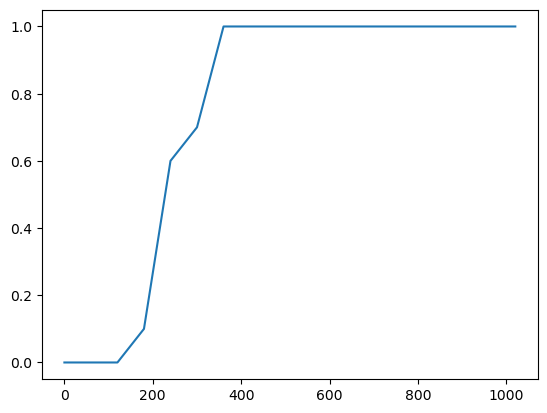

In [9]:
fileHandle = PP.openLMFile(f'{simsDir}{geneCheck}.lm')

CMEspecies = PP.getSpecies(fileHandle)
specList = [spec.decode('utf-8') for spec in CMEspecies]

avTot = None
isoforms = 0
rnaMade = 0
for i in range(len(specList)):
    spec = specList[i]
    CMEid = CMEspecies[i]
    # print(spec)
    if spec.startswith('m_'):
        isoforms+=1
        av, var, t = PP.getAvgVarTrace(fileHandle, specie=CMEid)
        
        if avTot is None:
            avTot = av
        else:
            avTot = avTot + av

        if av[-1]>0.001:
            rnaMade+=1
print(avTot[-1])
plt.plot(t,avTot)
plt.show()
PP.closeLMFile(fileHandle)

In [13]:
def summarizeGeneData(geneID):

    # with lock:
    geneDict = {}

    geneDict[geneID] = {}

    jsonFile = f'{simsDir}json/{geneID}.json'

    # print(geneID)

    try:
        fileHandle = PP.openLMFile(f'{simsDir}{geneID}.lm')
    except:
        geneDict[geneID]['noSim'] = 1
        with open(jsonFile, 'w') as fp:
            json.dump(geneDict, fp)
        return None
        
    CMEspecies = PP.getSpecies(fileHandle)
    specList = [spec.decode('utf-8') for spec in CMEspecies]

    avTot = None
    isoforms = 0
    mrnaMade = 0
    for i in range(len(specList)):
        spec = specList[i]
        CMEid = CMEspecies[i]
        # print(spec)
        if spec.startswith('m_'):
    #         # print(spec)
    #         mrna.append(CMEid)
    
    
    # for spec in speciesList:
    #     if spec.startswith('m_'):
    #         # print(spec)
            isoforms+=1
            try:
                av, var, t = PP.getAvgVarTrace(fileHandle, specie=CMEid)
            except:
                geneDict[geneID]['Error'] = 1
                break
            
            if avTot is None:
                avTot = av
            else:
                avTot = avTot + av
    
            if av[-1]>0.001:
                mrnaMade+=1
    
    if avTot is not None:
        if avTot[-1]<0.9999:
            geneDict[geneID]['FailedSplice'] = avTot[-1]
    
        geneDict[geneID]['isoforms'] = isoforms
        geneDict[geneID]['mrnaMade'] = mrnaMade
    
    PP.closeLMFile(fileHandle)

    # print(geneDict)

    # with open(pklFile, 'wb') as file:
    #     # Use pickle.dump() to serialize the dictionary and write it to the file
    #     pickle.dump(geneDict, file)

    
    with open(jsonFile, 'w') as fp:
        json.dump(geneDict, fp)

    return None

In [14]:
geneDict = {}
startTime = TIME.time()

In [15]:
for geneID in geneList:
    summarizeGeneData(geneID)
    if geneList.index(geneID) % 1000 == 0:
        print(geneList.index(geneID), f': Total Time Elapsed {TIME.time()-startTime}')

0 : Total Time Elapsed 0.226182222366333
1000 : Total Time Elapsed 38.407490968704224
2000 : Total Time Elapsed 76.60740971565247
3000 : Total Time Elapsed 112.96743774414062
4000 : Total Time Elapsed 147.7411494255066
5000 : Total Time Elapsed 184.46238446235657
6000 : Total Time Elapsed 220.77322125434875
7000 : Total Time Elapsed 254.83720350265503
8000 : Total Time Elapsed 288.60556745529175
9000 : Total Time Elapsed 318.84363770484924
10000 : Total Time Elapsed 344.45202684402466
11000 : Total Time Elapsed 361.3139400482178
12000 : Total Time Elapsed 373.0896167755127


In [ ]:
break

In [16]:
testGene = 'SRSF6'
testFile = f'{simsDir}json/{testGene}.json'
print(testFile)

with open(testFile, 'rb') as handle:
    b = json.load(handle)

b

/Data1/zane/Zenodo/isosplicer_code_and_data/Data/Multi_Isoform_Genes_Cotrsc/json/SRSF6.json


{'SRSF6': {'isoforms': 2, 'mrnaMade': 1}}